### Aggregate all the metrics and create a plot

In [1]:
import pandas as pd
import os

scratch_dir = os.environ.get("SCRATCH")
PATH_DIR = os.path.join(scratch_dir, "projects/MindEyeV2/src/mindeyev2/evals/")
MODEL_NAME = "sub-005_ses-01_task-C_bs24_MST_rishab_repeats_3split_{idx}_avgrepeats_finalmask_epochs_{epochs}"

df_list = []
for idx in range(1, 11):
    epochs = idx * 15
    df_epoch = pd.read_csv(os.path.join(PATH_DIR, MODEL_NAME.format(idx=idx, epochs=epochs), "final_evals.csv"))
    df_epoch['epochs'] = epochs
    df_list.append(df_epoch)

df = pd.concat(df_list)

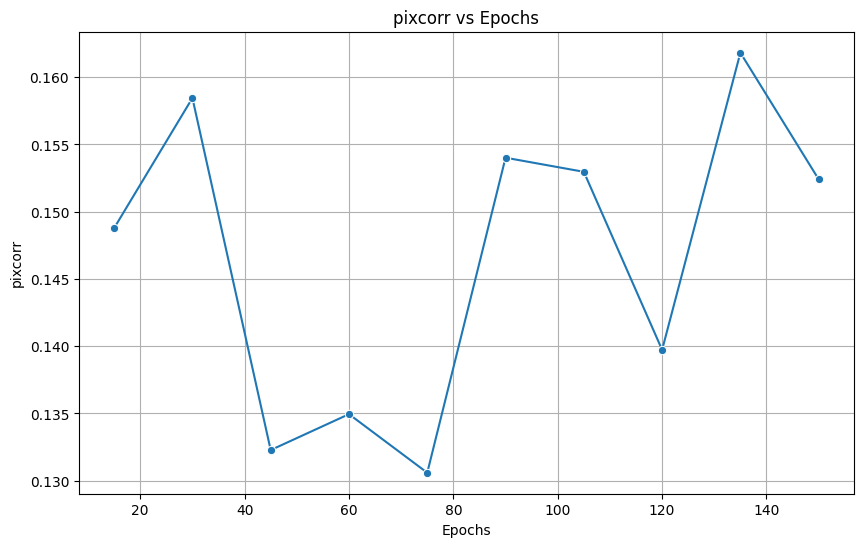

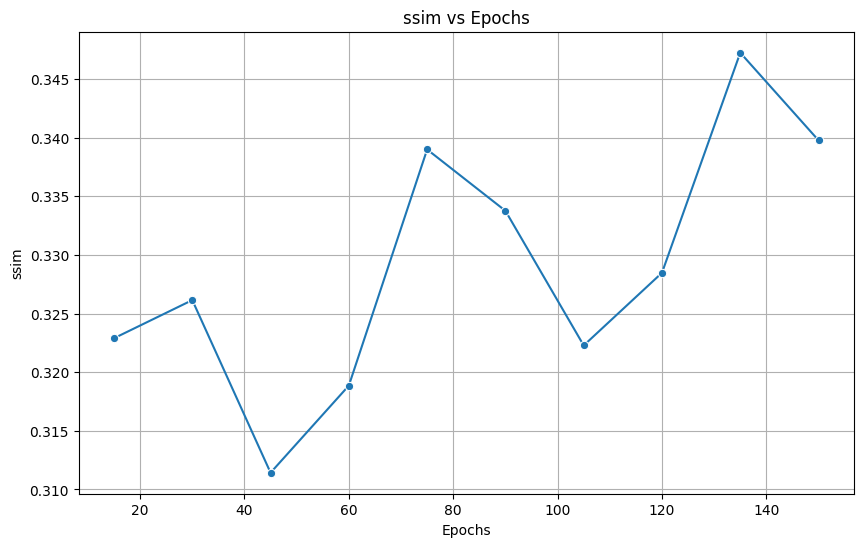

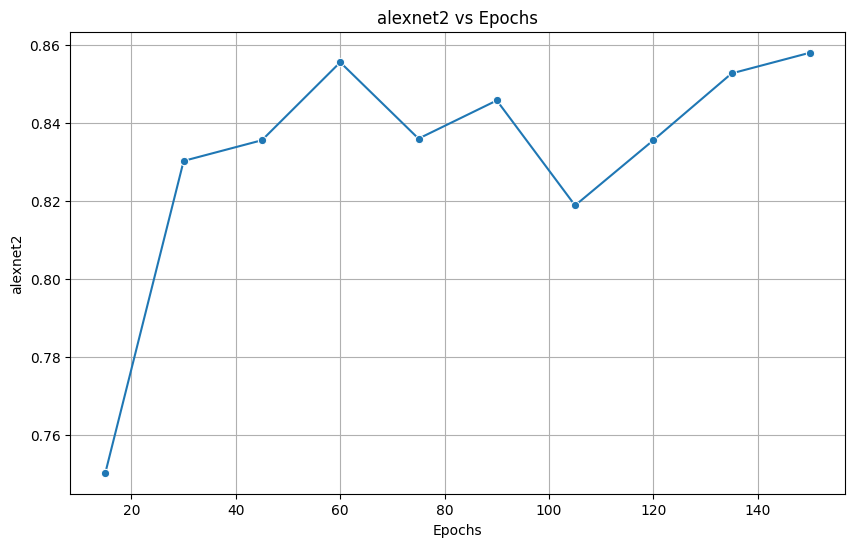

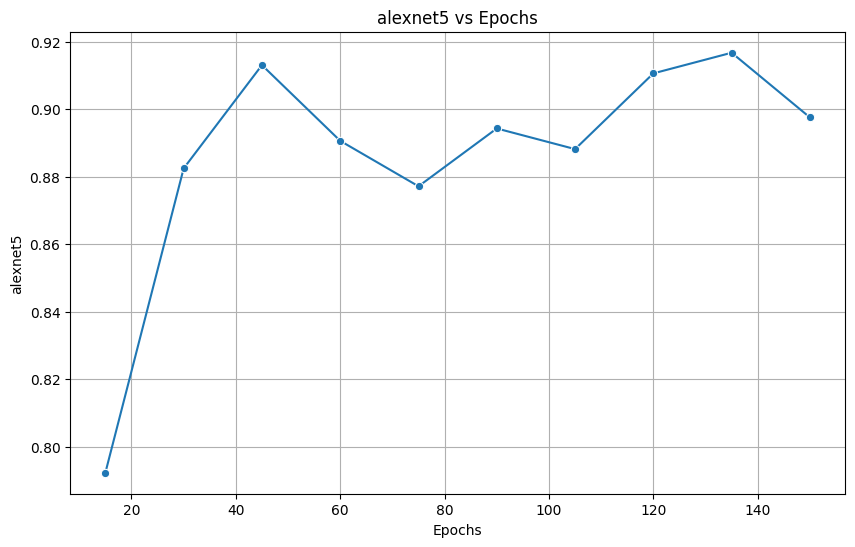

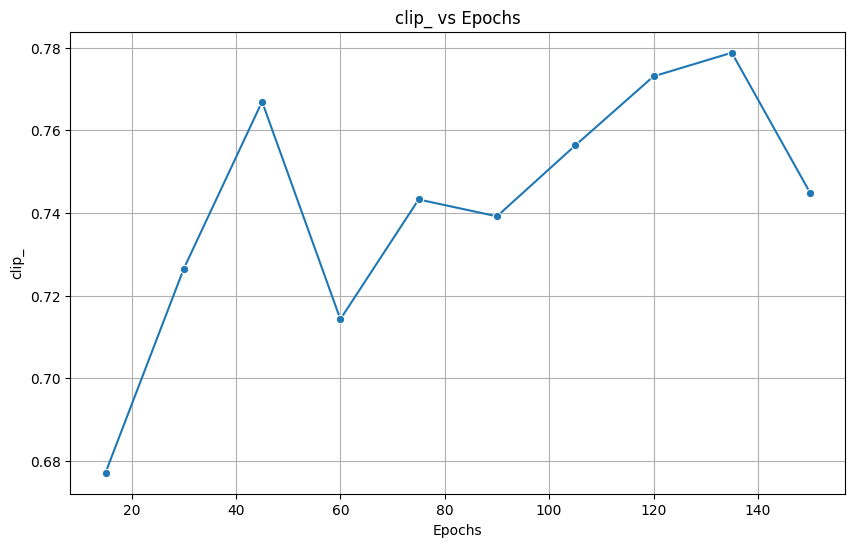

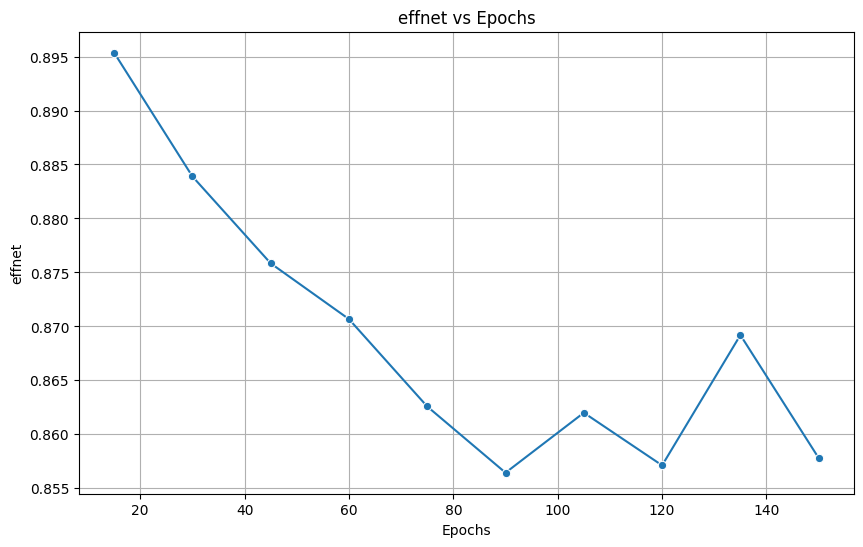

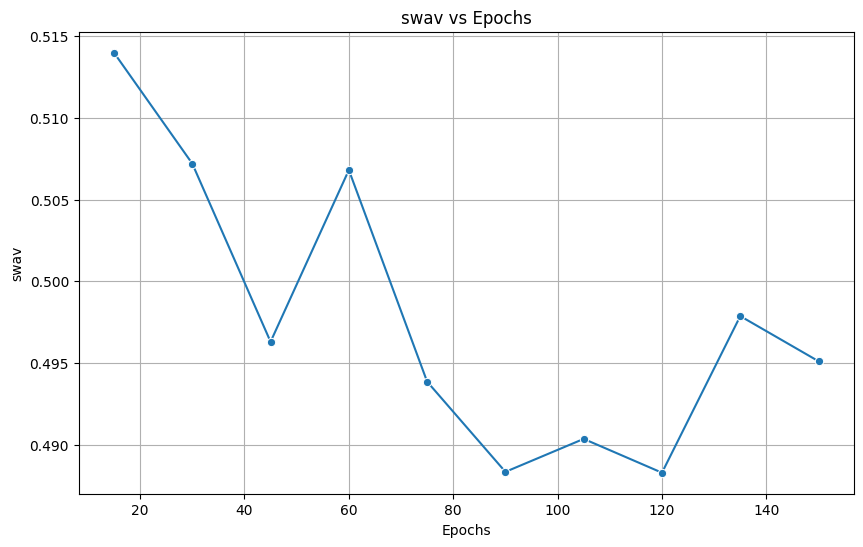

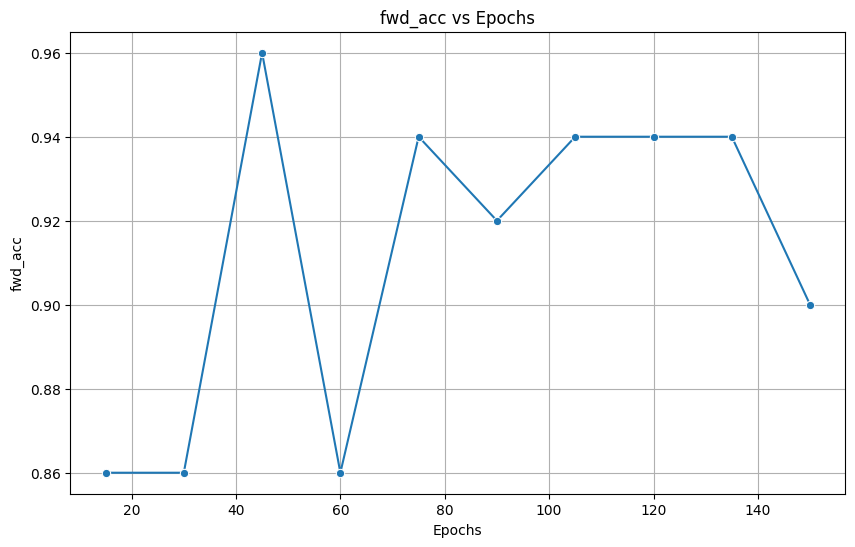

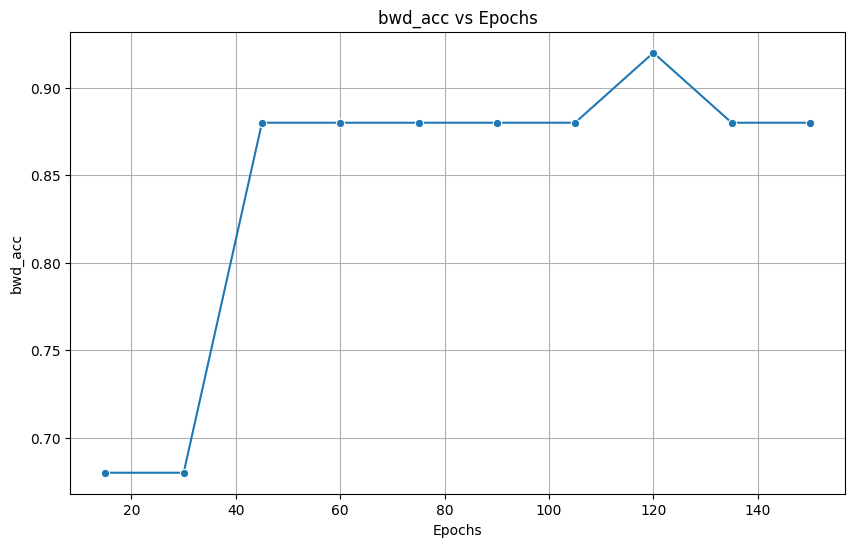

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

metric_names = df['metric'].unique().tolist()
epochs = sorted(df['epochs'].unique().tolist())
for metric in metric_names:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df[df['metric'] == metric][['values', 'epochs']], x='epochs', y='values', marker='o')
    plt.title(f'{metric} vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.grid(True)
    # plt.savefig(os.path.join(PATH_DIR, f'aggregate_{metric}_vs_epochs.png'))
    # plt.close()
    plt.show()

## Load reconstructions and ground-truth images

In [3]:
import torch
from tqdm import tqdm

all_images, all_recons = [], []
for idx in tqdm(range(1, 11)):
    epochs = idx * 15
    epoch_model_name = MODEL_NAME.format(idx=idx, epochs=epochs)
    all_images.append(torch.load(os.path.join(PATH_DIR, epoch_model_name, f"{epoch_model_name}_all_images.pt")))
    all_recons.append(torch.load(os.path.join(PATH_DIR, epoch_model_name, f"{epoch_model_name}_all_recons.pt")))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.36it/s]


In [4]:
all_images[0].shape

torch.Size([50, 3, 256, 256])

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def tensor_to_numpy(tensor):
    # Convert tensor shape (3,H,W) to (H,W,3), normalize, and convert to numpy uint8
    tensor = tensor.detach().cpu()
    if tensor.ndim == 3 and tensor.shape[0] == 3:
        np_img = tensor.permute(1, 2, 0).numpy()
        np_img = (np_img - np_img.min()) / (np_img.max() - np_img.min())
    elif tensor.ndim == 2:
        np_img = tensor.numpy()
        np_img = (np_img - np_img.min()) / (np_img.max() - np_img.min())
    else:
        raise ValueError("Unsupported tensor shape")
    return (np_img * 255).astype(np.uint8)

def plot_epoch_grid(epoch_idx):
    gt_batch = all_images[epoch_idx]   # Shape: (50, 3, 256, 256)
    recon_batch = all_recons[epoch_idx] # Shape: (50, 3, 256, 256)

    n_images = gt_batch.shape[0]  # 50
    n_cols = 10
    n_rows = n_images // n_cols

    fig, axs = plt.subplots(n_rows, n_cols * 2, figsize=(20, n_rows * 2))
    fig.suptitle(f'Epoch {(epoch_idx + 1) * 15} Ground Truth (L) vs Reconstruction (R)', fontsize=16)

    for i in range(n_images):
        row = i // n_cols
        col = i % n_cols

        gt_img = tensor_to_numpy(gt_batch[i])
        recon_img = tensor_to_numpy(recon_batch[i])

        # Plot ground-truth image left
        axs[row, col * 2].imshow(gt_img)
        axs[row, col * 2].axis('off')
        if row == 0:
            axs[row, col * 2].set_title(f'GT {i}')

        # Plot reconstruction image right
        axs[row, col * 2 + 1].imshow(recon_img)
        axs[row, col * 2 + 1].axis('off')
        if row == 0:
            axs[row, col * 2 + 1].set_title(f'Recon {i}')

    plt.tight_layout()
    plt.show()

interact(plot_epoch_grid, epoch_idx=IntSlider(min=0, max=len(all_images)-1, step=1, value=0))


interactive(children=(IntSlider(value=0, description='epoch_idx', max=9), Output()), _dom_classes=('widget-int…

<function __main__.plot_epoch_grid(epoch_idx)>

### Analyze recons and visualize embeddings

In [37]:
EPOCH_TO_LOAD = 135
idx = EPOCH_TO_LOAD // 15
model_to_load = MODEL_NAME.format(idx=idx, epochs=EPOCH_TO_LOAD)
eval_dir = os.path.join(scratch_dir, "projects/MindEyeV2/src/mindeyev2/evals/", model_to_load)
print(model_to_load)

sub-005_ses-01_task-C_bs24_MST_rishab_repeats_3split_9_avgrepeats_finalmask_epochs_135


### Load all data

In [38]:
# load test data
clip_voxels = torch.load(os.path.join(PATH_DIR, model_to_load, f"{model_to_load}_all_clipvoxels.pt"))
test_images = all_images[idx - 1]
test_recons = all_images[idx - 1]

### Load all models

In [ ]:
print("importing modules")
import os
import sys
import numpy as np
from tqdm import tqdm

import torch

# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True

import utils

# this block imports utils from mindeye_preproc as "preproc"
import importlib.util
parent_utils_path = "/scratch/am10150/projects/mindeye_preproc/analysis/utils.py"
spec = importlib.util.spec_from_file_location("utils", parent_utils_path)
preproc = importlib.util.module_from_spec(spec)
parent_dir = os.path.dirname(parent_utils_path)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
spec.loader.exec_module(preproc)

if utils.is_interactive():
    from IPython.display import clear_output # function to clear print outputs in cell
    %load_ext autoreload 
    # this allows you to change functions in models.py or utils.py and have this notebook automatically update with your revisions
    %autoreload 2 

importing modules


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
## USING OpenCLIP ViT-bigG ###
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder

print("loading clip model...")
clip_img_embedder = FrozenOpenCLIPImageEmbedder(
    arch="ViT-bigG-14",
    version="laion2b_s39b_b160k",
    output_tokens=True,
    only_tokens=True,
)
clip_img_embedder.to(device)

clip_seq_dim = 256
clip_emb_dim = 1664

/scratch/am10150/projects/rtcloud-projects/mindeye/conf/.venv/lib64/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


loading clip model...


In [10]:
hidden_dim=1024
n_blocks=4
num_voxels_list = [2792]
use_prior = True
clip_scale = 1

model = utils.prepare_model_and_training(
    num_voxels_list=num_voxels_list,
    n_blocks=n_blocks,
    hidden_dim=hidden_dim,
    clip_emb_dim=clip_emb_dim,
    clip_seq_dim=clip_seq_dim,
    use_prior=use_prior,
    clip_scale=clip_scale
)

MindEyeModule()
param counts:
2,860,032 total
2,860,032 trainable
param counts:
2,860,032 total
2,860,032 trainable
param counts:
453,360,280 total
453,360,280 trainable
param counts:
456,220,312 total
456,220,312 trainable
param counts:
259,865,216 total
259,865,200 trainable
param counts:
716,085,528 total
716,085,512 trainable


In [11]:
# Load pretrained model ckpt
tag='last'
ckpt_dir = os.path.join(scratch_dir, "projects/MindEyeV2/src/mindeyev2/train_logs/")

outdir = os.path.join(ckpt_dir, model_to_load)

print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
checkpoint = torch.load(os.path.join(outdir, f'{tag}.pth'), map_location='cpu')
state_dict = checkpoint['model_state_dict']
model.load_state_dict(state_dict, strict=True)
del checkpoint

model.to(device)
print("ckpt loaded!")


---loading /scratch/am10150/projects/MindEyeV2/src/mindeyev2/train_logs/sub-005_ses-01_task-C_bs24_MST_rishab_repeats_3split_2_avgrepeats_finalmask_epochs_30/last.pth ckpt---



ckpt loaded!


In [12]:
# prep unCLIP
from omegaconf import OmegaConf
from generative_models.sgm.models.diffusion import DiffusionEngine

config = OmegaConf.load(os.path.join(scratch_dir, "projects/MindEyeV2/src/generative_models/configs/unclip6.yaml"))
config = OmegaConf.to_container(config, resolve=True)
unclip_params = config["model"]["params"]
network_config = unclip_params["network_config"]
denoiser_config = unclip_params["denoiser_config"]
first_stage_config = unclip_params["first_stage_config"]
conditioner_config = unclip_params["conditioner_config"]
sampler_config = unclip_params["sampler_config"]
scale_factor = unclip_params["scale_factor"]
disable_first_stage_autocast = unclip_params["disable_first_stage_autocast"]
offset_noise_level = unclip_params["loss_fn_config"]["params"]["offset_noise_level"]

first_stage_config['target'] = 'sgm.models.autoencoder.AutoencoderKL'
sampler_config['params']['num_steps'] = 38

diffusion_engine = DiffusionEngine(network_config=network_config,
                       denoiser_config=denoiser_config,
                       first_stage_config=first_stage_config,
                       conditioner_config=conditioner_config,
                       sampler_config=sampler_config,
                       scale_factor=scale_factor,
                       disable_first_stage_autocast=disable_first_stage_autocast)
# set to inference
diffusion_engine.eval().requires_grad_(False)
diffusion_engine.to(device)

ckpt_path = os.path.join(scratch_dir, 'projects/MindEyeV2/src/mindeyev2_data/unclip6_epoch0_step110000.ckpt') 
ckpt = torch.load(ckpt_path, map_location='cpu')
diffusion_engine.load_state_dict(ckpt['state_dict'])

batch={"jpg": torch.randn(1,3,1,1).to(device), # jpg doesnt get used, it's just a placeholder
      "original_size_as_tuple": torch.ones(1, 2).to(device) * 768,
      "crop_coords_top_left": torch.zeros(1, 2).to(device)}
out = diffusion_engine.conditioner(batch)
vector_suffix = out["vector"].to(device)
print("vector_suffix", vector_suffix.shape)

Initialized embedder #0: FrozenOpenCLIPImageEmbedder with 1909889025 params. Trainable: False
Initialized embedder #1: ConcatTimestepEmbedderND with 0 params. Trainable: False
Initialized embedder #2: ConcatTimestepEmbedderND with 0 params. Trainable: False
vector_suffix torch.Size([1, 1024])


### Test: Plot of test and gt embeddings

In [39]:
# # --- Start of Snippet 1 ---

# # Let's use a larger batch for a more stable analysis
debug_batch_size = 62 
if len(test_images) < debug_batch_size:
    debug_batch_size = len(test_images) # Adjust if your test set is smaller

# Select the fMRI data and corresponding ground truth images for this batch
# test_voxels are clip_voxels
test_voxels = torch.load(os.path.join(eval_dir, f"{model_to_load}_all_prior_out.pt"))
predicted_clip_embeddings = test_voxels[:debug_batch_size].unsqueeze(1)
images_for_debug = test_images[:debug_batch_size].to(device)
model.to(device)

print("Generating ground truth CLIP embeddings from images...")
with torch.no_grad():
    # Generate the "perfect" CLIP embeddings directly from the images
    ground_truth_clip_embeddings = clip_img_embedder(images_for_debug).cpu()

print("\nShapes of embeddings:")
print("Predicted:", predicted_clip_embeddings.shape)
print("Ground Truth:", ground_truth_clip_embeddings.shape)

# # --- End of Snippet 1 ---

Generating ground truth CLIP embeddings from images...

Shapes of embeddings:
Predicted: torch.Size([50, 1, 256, 1664])
Ground Truth: torch.Size([50, 256, 1664])


In [40]:
# # --- Start of Snippet 2 ---

import torch.nn.functional as F

# Flatten the embeddings to compare them as single vectors per image
# Shape changes from (batch, seq_len, dim) to (batch, seq_len * dim)
predicted_flat = predicted_clip_embeddings.flatten(1)
ground_truth_flat = ground_truth_clip_embeddings.flatten(1)

# 1. Cosine Similarity (should be high, confirming your retrieval results)
cos_sim = F.cosine_similarity(predicted_flat, ground_truth_flat).mean()

# 2. Mean Squared Error (MSE)
mse = F.mse_loss(predicted_flat, ground_truth_flat)

print(f"--- Quantitative Analysis (for batch of {debug_batch_size}) ---")
print(f"Average Cosine Similarity: {cos_sim.item():.4f}")
print(f"Mean Squared Error (MSE):  {mse.item():.4f}")

# # --- End of Snippet 2 ---

--- Quantitative Analysis (for batch of 50) ---
Average Cosine Similarity: 0.3340
Mean Squared Error (MSE):  1.6572



Fitting PCA to visualize embedding spaces...


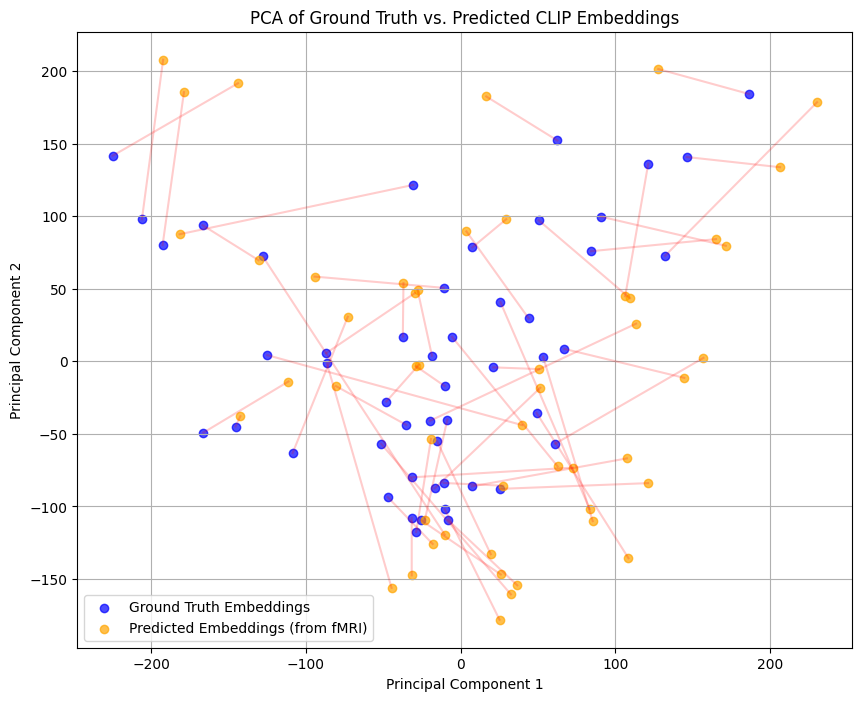

In [41]:
# # --- Start of Snippet 3 ---

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine both sets of embeddings for PCA
combined_embeddings = torch.cat((ground_truth_flat, predicted_flat), dim=0).numpy()
# np.random.seed(42)

print("\nFitting PCA to visualize embedding spaces...")
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(combined_embeddings)

# Separate the transformed embeddings back into ground truth and predicted
gt_2d = embeddings_2d[:debug_batch_size]
pred_2d = embeddings_2d[debug_batch_size:]

# Create the plot
plt.figure(figsize=(10, 8))
plt.scatter(gt_2d[:, 0], gt_2d[:, 1], alpha=0.7, label='Ground Truth Embeddings', c='blue')
plt.scatter(pred_2d[:, 0], pred_2d[:, 1], alpha=0.7, label='Predicted Embeddings (from fMRI)', c='orange')

# Optional: Draw lines connecting corresponding points
for i in range(debug_batch_size):
    plt.plot([gt_2d[i, 0], pred_2d[i, 0]], [gt_2d[i, 1], pred_2d[i, 1]], 'r-', alpha=0.2)

plt.title('PCA of Ground Truth vs. Predicted CLIP Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# # --- End of Snippet 3 ---

### test reconstructions

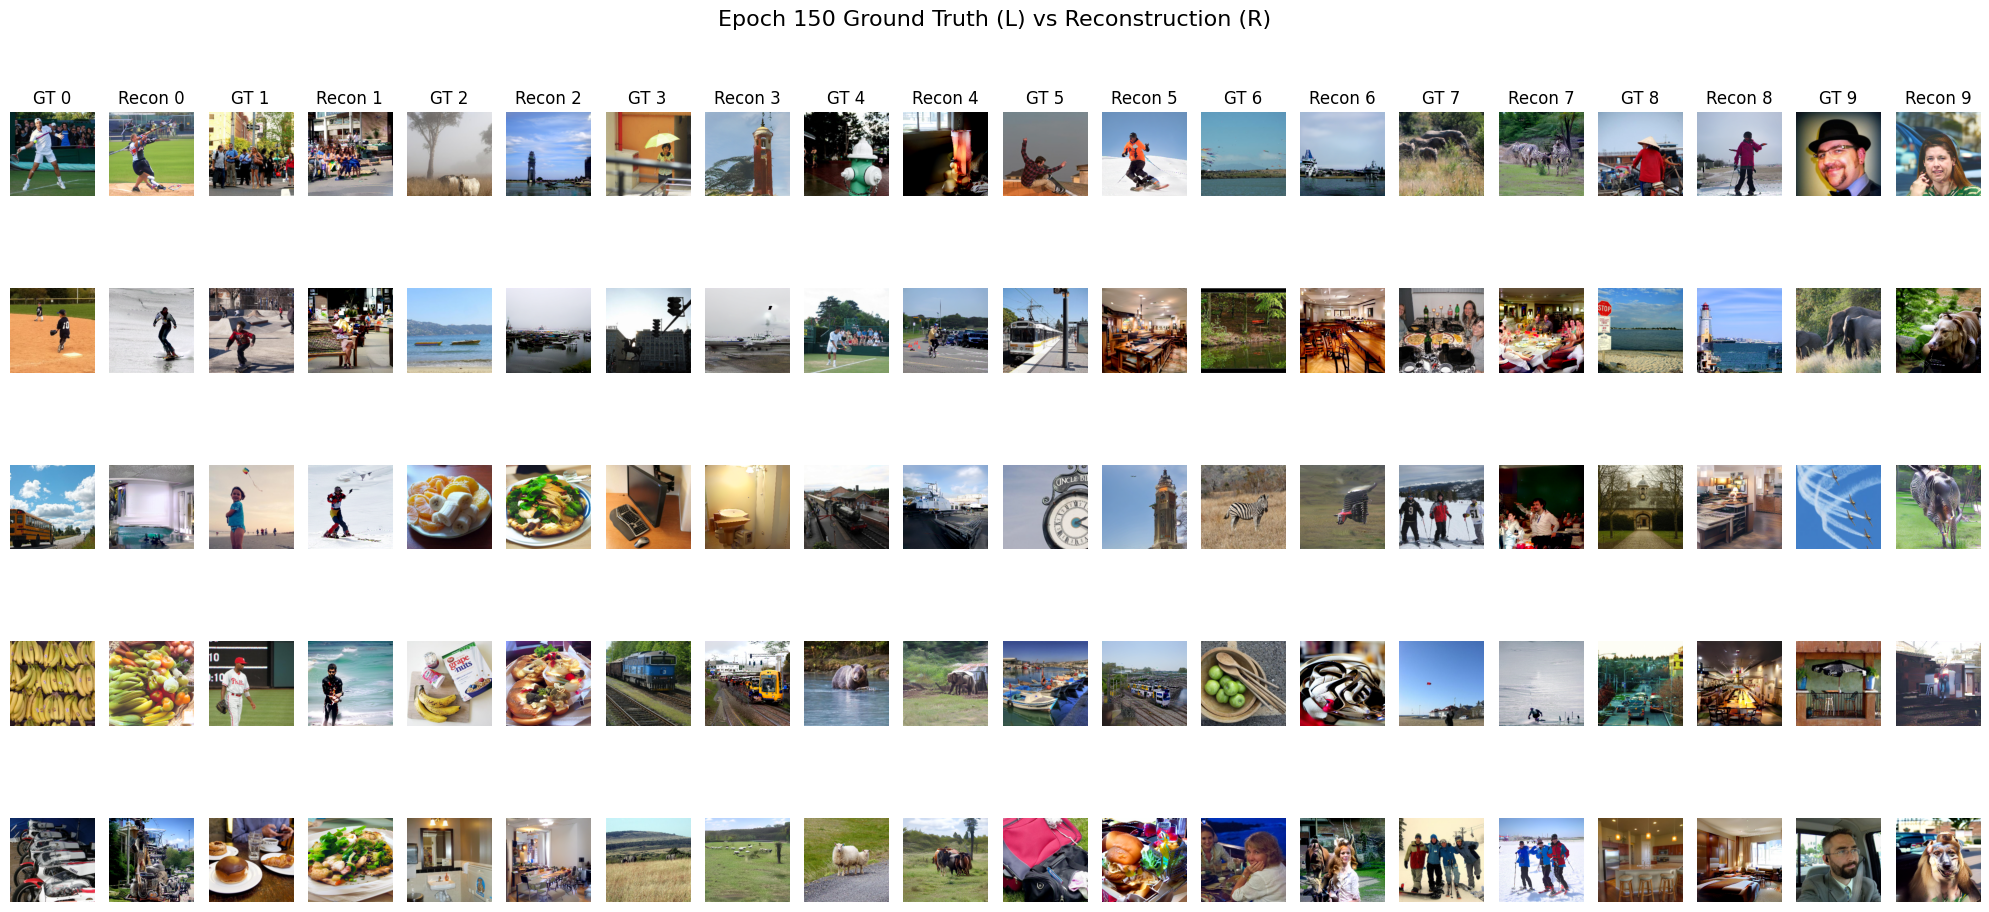

In [42]:
plot_epoch_grid(EPOCH_TO_LOAD // 15)

In [43]:
# # --- Start of Snippet 1: Load Train Data ---

# # Make sure you are in the same directory or provide the correct path to your eval_dir
# # This file was saved during the training run
train_image_indices = np.load(f"{eval_dir}/train_image_indices.npy")
print(f"Loaded {len(train_image_indices)} training indices.")

# Let's select a random subset of the training data for a quick and representative analysis
debug_batch_size = 32
if len(train_image_indices) < debug_batch_size:
    debug_batch_size = len(train_image_indices)

# Select random indices from the training set
np.random.seed(42) # for reproducibility
random_train_indices = np.random.choice(train_image_indices, size=debug_batch_size, replace=False)

# Get the corresponding fMRI data and images
# Note: We load the train `vox` and `images` tensors saved during training
vox_train, images_train = np.load(f"{eval_dir}/vox.npy"), np.load(f"{eval_dir}/images.npy")
vox_train, images_train = torch.from_numpy(vox_train), torch.from_numpy(images_train)
voxels_for_train_debug = vox_train[random_train_indices].unsqueeze(1).to(device)
images_for_train_debug = images_train[random_train_indices].to(device)

print("\nShapes for analysis:")
print("Train Voxels:", voxels_for_train_debug.shape)
print("Train Images:", images_for_train_debug.shape)

# # --- End of Snippet 1 ---

Loaded 481 training indices.



Shapes for analysis:
Train Voxels: torch.Size([32, 1, 2792])
Train Images: torch.Size([32, 3, 224, 224])


Generating predicted CLIP embeddings from training fMRI data...


sampling loop time step:   0%|          | 0/19 [00:00<?, ?it/s]

Generating ground truth CLIP embeddings from training images...

--- Quantitative Analysis (for TRAIN batch of 32) ---
Average Cosine Similarity: 0.4490
Mean Squared Error (MSE):  1.3725
(For comparison, your test set MSE was ~1.73)

Fitting PCA for training set visualization...


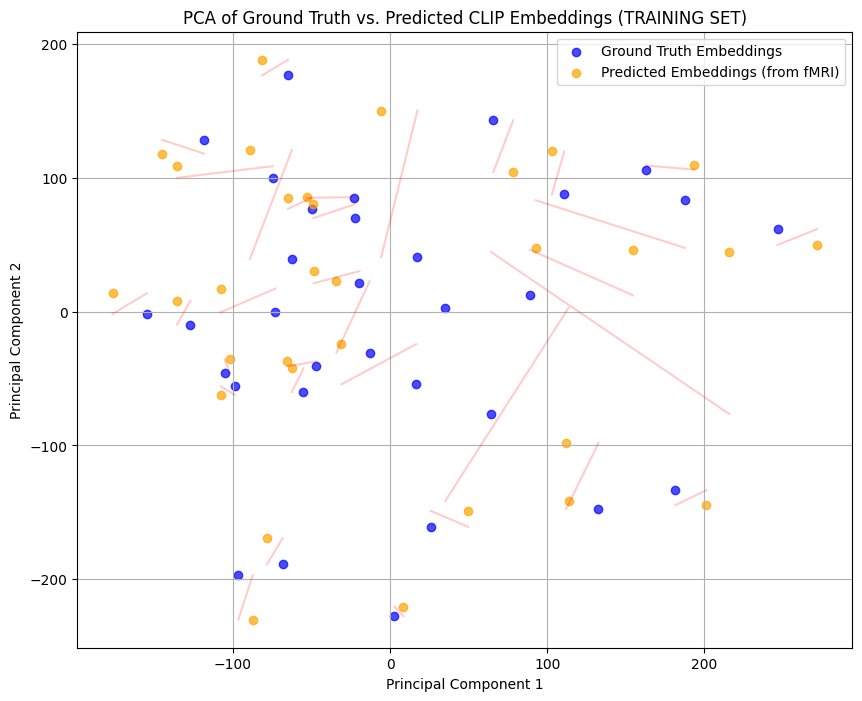

In [44]:
# # --- Start of Snippet 2: Analyze Train Embeddings ---

import torch.nn.functional as F
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Generate predicted embeddings from the model
print("Generating predicted CLIP embeddings from training fMRI data...")
with torch.no_grad():
    voxel_ridge_train = model.ridge(voxels_for_train_debug, 0)
    backbone_train, _, _ = model.backbone(voxel_ridge_train)
    predicted_clip_embeddings_train = model.diffusion_prior.p_sample_loop(
        backbone_train.shape, 
        text_cond=dict(text_embed=backbone_train), 
        cond_scale=1., 
        timesteps=20
    ).cpu()

# Generate ground truth embeddings from the images
print("Generating ground truth CLIP embeddings from training images...")
with torch.no_grad():
    ground_truth_clip_embeddings_train = clip_img_embedder(images_for_train_debug).cpu()

# --- Quantitative Analysis ---
predicted_flat_train = predicted_clip_embeddings_train.flatten(1)
ground_truth_flat_train = ground_truth_clip_embeddings_train.flatten(1)
cos_sim_train = F.cosine_similarity(predicted_flat_train, ground_truth_flat_train).mean()
mse_train = F.mse_loss(predicted_flat_train, ground_truth_flat_train)

print(f"\n--- Quantitative Analysis (for TRAIN batch of {debug_batch_size}) ---")
print(f"Average Cosine Similarity: {cos_sim_train.item():.4f}")
print(f"Mean Squared Error (MSE):  {mse_train.item():.4f}")
print(f"(For comparison, your test set MSE was ~1.73)")

# --- PCA Visualization ---
combined_embeddings_train = torch.cat((ground_truth_flat_train, predicted_flat_train), dim=0).numpy()
print("\nFitting PCA for training set visualization...")
pca_train = PCA(n_components=2)
embeddings_2d_train = pca_train.fit_transform(combined_embeddings_train)
gt_2d_train = embeddings_2d_train[:debug_batch_size]
pred_2d_train = embeddings_2d_train[debug_batch_size:]

plt.figure(figsize=(10, 8))
plt.scatter(gt_2d_train[:, 0], gt_2d_train[:, 1], alpha=0.7, label='Ground Truth Embeddings', c='blue')
plt.scatter(pred_2d_train[:, 0], pred_2d_train[:, 1], alpha=0.7, label='Predicted Embeddings (from fMRI)', c='orange')
for i in range(debug_batch_size):
    plt.plot([gt_2d_train[i, 0], pred_2d_train[i, 0]], [pred_2d_train[i, 1], gt_2d_train[i, 1]], 'r-', alpha=0.2)
plt.title('PCA of Ground Truth vs. Predicted CLIP Embeddings (TRAINING SET)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# # --- End of Snippet 2 ---


Generating reconstructions from predicted training embeddings...


  0%|                                                                                                  | 0/32 [00:00<?, ?it/s]/scratch/am10150/projects/rtcloud-projects/mindeye/conf/.venv/lib64/python3.11/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/scratch/am10150/projects/rtcloud-projects/mindeye/conf/.venv/lib64/python3.11/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


100%|█████████████████████████████████████████████████████████████████████████████████████████| 32/32 [02:37<00:00,  4.93s/it]


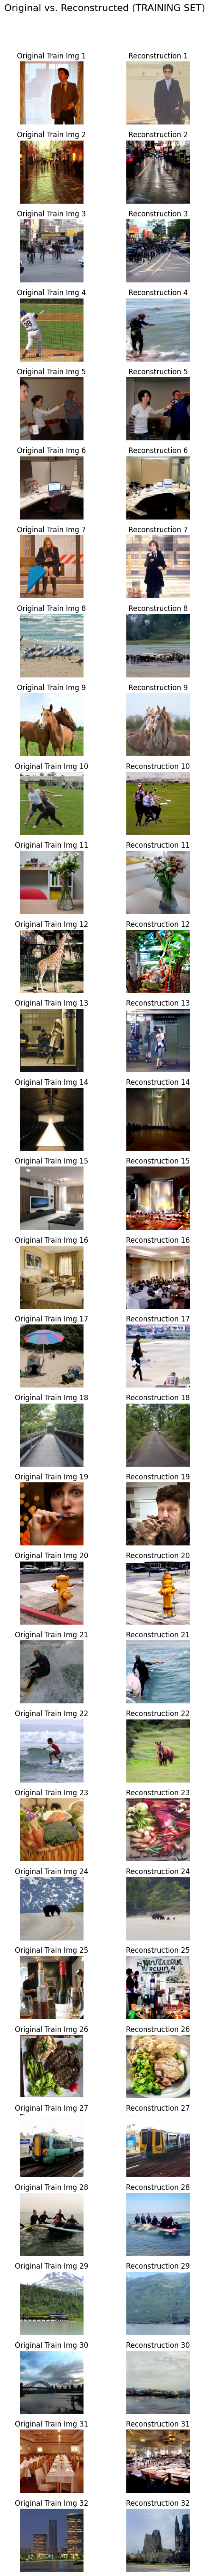

In [45]:
# # --- Start of Snippet 3: Reconstruct Train Images ---

reconstructions_from_train = []
print("\nGenerating reconstructions from predicted training embeddings...")

with torch.no_grad():
    for i in tqdm(range(debug_batch_size)):
        current_pred_embedding = predicted_clip_embeddings_train[[i]]
        
        samples = utils.unclip_recon(
            current_pred_embedding,
            diffusion_engine,
            vector_suffix,
            num_samples=1
        )
        reconstructions_from_train.append(samples.cpu())

reconstructions_from_train = torch.cat(reconstructions_from_train, dim=0)

# --- Visualization ---
fig, axes = plt.subplots(debug_batch_size, 2, figsize=(6, 2 * debug_batch_size))
fig.suptitle("Original vs. Reconstructed (TRAINING SET)", fontsize=16)

for i in range(debug_batch_size):
    # Plot Original Image
    ax = axes[i, 0]
    ax.imshow(utils.torch_to_Image(images_for_train_debug[i]))
    ax.set_title(f"Original Train Img {i+1}")
    ax.axis('off')

    # Plot Reconstructed Image
    ax = axes[i, 1]
    ax.imshow(utils.torch_to_Image(reconstructions_from_train[i]))
    ax.set_title(f"Reconstruction {i+1}")
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# # --- End of Snippet 3 ---
